# Phân tích Khám phá Dữ liệu (EDA) — Dự báo Nguy cơ Trả hàng (Order Return Prediction)

Notebook này thực hiện EDA cho bài toán phân loại nhị phân:
**Dự đoán liệu một đơn hàng có bị trả lại hay không, ngay tại thời điểm Checkout.**

## Thiết kế bài toán

| Yếu tố | Chi tiết |
| :--- | :--- |
| **Đơn vị dự báo** | `order_id` — 1 đơn hàng |
| **Thời điểm dự báo** | Ngay khi khách bấm "Đặt hàng" (Checkout) |
| **$y = 1$ (Return)** | Đơn hàng có **ít nhất 1 sản phẩm** bị trả lại |
| **$y = 0$ (Keep)** | Đơn hàng giao thành công, không có sản phẩm nào bị trả |
| **Scope** | Chỉ các đơn có `order_status` ∈ {`delivered`, `returned`} |

> **Nguyên tắc chống rò rỉ dữ liệu:** Tại thời điểm checkout, chúng ta **KHÔNG** biết `ship_date`, `delivery_date`, `return_date`, `return_reason`. Chỉ sử dụng thông tin có sẵn tại thời điểm đặt hàng.

## 1. Khởi tạo Môi trường & Tải dữ liệu

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Cấu hình đồ thị
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 11

DATA_DIR = r'./datathon-2026-round-1'
print('Thư viện đã sẵn sàng!')

Thư viện đã sẵn sàng!


In [2]:
# Đọc tất cả các bảng dữ liệu cần thiết
df_orders     = pd.read_csv(os.path.join(DATA_DIR, 'orders.csv'), parse_dates=['order_date'])
df_order_items = pd.read_csv(os.path.join(DATA_DIR, 'order_items.csv'), low_memory=False)
df_returns    = pd.read_csv(os.path.join(DATA_DIR, 'returns.csv'), parse_dates=['return_date'])
df_products   = pd.read_csv(os.path.join(DATA_DIR, 'products.csv'))
df_customers  = pd.read_csv(os.path.join(DATA_DIR, 'customers.csv'), parse_dates=['signup_date'])
df_reviews    = pd.read_csv(os.path.join(DATA_DIR, 'reviews.csv'), parse_dates=['review_date'])
df_geography  = pd.read_csv(os.path.join(DATA_DIR, 'geography.csv'))

print(f'Orders:      {df_orders.shape[0]:>10,} rows')
print(f'Order Items: {df_order_items.shape[0]:>10,} rows')
print(f'Returns:     {df_returns.shape[0]:>10,} rows')
print(f'Products:    {df_products.shape[0]:>10,} rows')
print(f'Customers:   {df_customers.shape[0]:>10,} rows')
print(f'Reviews:     {df_reviews.shape[0]:>10,} rows')
print(f'Geography:   {df_geography.shape[0]:>10,} rows')

Orders:         646,945 rows
Order Items:    714,669 rows
Returns:         39,939 rows
Products:         2,412 rows
Customers:      121,930 rows
Reviews:        113,551 rows
Geography:       39,948 rows


## 2. Xây dựng Tập dữ liệu & Gắn nhãn Mục tiêu ($y$)

Đơn vị dự báo là **đơn hàng** (`order_id`). Chỉ giữ lại các đơn đã hoàn thành (`delivered` hoặc `returned`).

- $y = 1$: Đơn hàng có ít nhất 1 sản phẩm bị trả lại
- $y = 0$: Không sản phẩm nào bị trả lại

In [3]:
# Lọc đơn hàng đủ điều kiện
eligible_statuses = ['delivered', 'returned']
df_eligible = df_orders[df_orders['order_status'].isin(eligible_statuses)].copy()
print(f'Đơn hàng đủ điều kiện: {df_eligible.shape[0]:,}')
print(f'  - Delivered: {(df_eligible["order_status"] == "delivered").sum():,}')
print(f'  - Returned:  {(df_eligible["order_status"] == "returned").sum():,}')

# Loại bỏ:
excluded = df_orders[~df_orders['order_status'].isin(eligible_statuses)]
print(f'\nĐơn hàng bị loại bỏ: {excluded.shape[0]:,}')
print(excluded['order_status'].value_counts().to_string())

Đơn hàng đủ điều kiện: 552,858
  - Delivered: 516,716
  - Returned:  36,142

Đơn hàng bị loại bỏ: 94,087
order_status
cancelled    59462
shipped      13773
paid         13577
created       7275


In [4]:
# Gắn nhãn mục tiêu y ở cấp order_id
# y=1 nếu order_id xuất hiện trong bảng returns (có ít nhất 1 sản phẩm bị trả)
returned_orders = df_returns['order_id'].unique()
df_eligible['is_returned'] = df_eligible['order_id'].isin(returned_orders).astype(int)

# Tạo bảng dữ liệu chính ở cấp order
df_data = df_eligible.copy()

print(f'Tập dữ liệu: {df_data.shape[0]:,} đơn hàng')
print(f'\n--- Phân phối biến mục tiêu y ---')
print(f'  y=0 (Keep):   {(df_data["is_returned"] == 0).sum():>10,} ({(df_data["is_returned"] == 0).mean()*100:.2f}%)')
print(f'  y=1 (Return): {(df_data["is_returned"] == 1).sum():>10,} ({(df_data["is_returned"] == 1).mean()*100:.2f}%)')

Tập dữ liệu: 552,858 đơn hàng

--- Phân phối biến mục tiêu y ---
  y=0 (Keep):      516,796 (93.48%)
  y=1 (Return):     36,062 (6.52%)


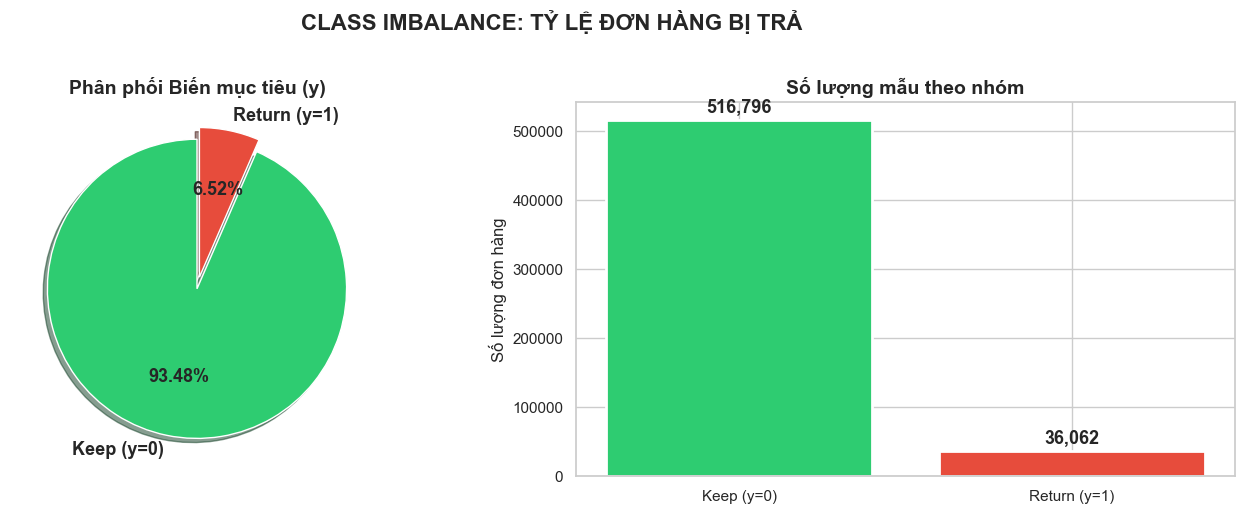

In [5]:
# Trực quan hóa tỷ lệ Class Imbalance
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Pie chart
labels = ['Keep (y=0)', 'Return (y=1)']
sizes = [df_data['is_returned'].value_counts()[0], df_data['is_returned'].value_counts()[1]]
colors_pie = ['#2ecc71', '#e74c3c']
explode = (0, 0.08)
axes[0].pie(sizes, explode=explode, labels=labels, colors=colors_pie, autopct='%1.2f%%',
            shadow=True, startangle=90, textprops={'fontsize': 13, 'fontweight': 'bold'})
axes[0].set_title('Phân phối Biến mục tiêu (y)', fontsize=14, fontweight='bold')

# 2. Bar chart với số lượng
bars = axes[1].bar(labels, sizes, color=colors_pie, edgecolor='white', linewidth=2)
for bar, size in zip(bars, sizes):
    axes[1].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 5000,
                 f'{size:,}', ha='center', va='bottom', fontsize=13, fontweight='bold')
axes[1].set_title('Số lượng mẫu theo nhóm', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Số lượng đơn hàng')

plt.suptitle('CLASS IMBALANCE: TỶ LỆ ĐƠN HÀNG BỊ TRẢ', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 3. Tổng hợp thông tin Sản phẩm lên cấp Đơn hàng

Vì đơn vị dự báo là `order_id`, chúng ta cần aggregate thông tin sản phẩm và line-items lên cấp đơn hàng.

In [6]:
# Ghép thông tin sản phẩm vào order_items
df_items = df_order_items.merge(df_products, on='product_id', how='left')

# Tính line_total cho mỗi item
df_items['line_total'] = df_items['quantity'] * df_items['unit_price'] - df_items['discount_amount']
df_items['has_discount'] = (df_items['discount_amount'] > 0).astype(int)
df_items['has_promo'] = df_items['promo_id'].notna().astype(int)

# Aggregate lên cấp order_id
order_agg = df_items.groupby('order_id').agg(
    n_products=('product_id', 'nunique'),
    n_items=('quantity', 'sum'),
    order_total_value=('line_total', 'sum'),
    avg_unit_price=('unit_price', 'mean'),
    max_unit_price=('unit_price', 'max'),
    min_unit_price=('unit_price', 'min'),
    total_discount=('discount_amount', 'sum'),
    has_any_discount=('has_discount', 'max'),
    has_any_promo=('has_promo', 'max'),
    n_categories=('category', 'nunique'),
    n_segments=('segment', 'nunique'),
    n_sizes=('size', 'nunique'),
    n_colors=('color', 'nunique'),
).reset_index()

# Merge vào df_data
df_data = df_data.merge(order_agg, on='order_id', how='left')

# Lấy category phổ biến nhất trong đơn
dominant_cat = df_items.groupby('order_id')['category'].agg(lambda x: x.mode().iloc[0] if len(x) > 0 else 'unknown').reset_index()
dominant_cat.columns = ['order_id', 'dominant_category']
df_data = df_data.merge(dominant_cat, on='order_id', how='left')

print(f'Dataset sau aggregate: {df_data.shape[0]:,} rows × {df_data.shape[1]} columns')
print(f'\nOrder aggregates:')
print(f'  avg n_products per order: {df_data["n_products"].mean():.2f}')
print(f'  avg order_total_value: {df_data["order_total_value"].mean():.0f}')

Dataset sau aggregate: 552,858 rows × 23 columns

Order aggregates:
  avg n_products per order: 1.10
  avg order_total_value: 24209


## 4. Thống kê Tổng quan bảng Returns

Khám phá bảng `returns.csv` trước khi phân tích sâu.

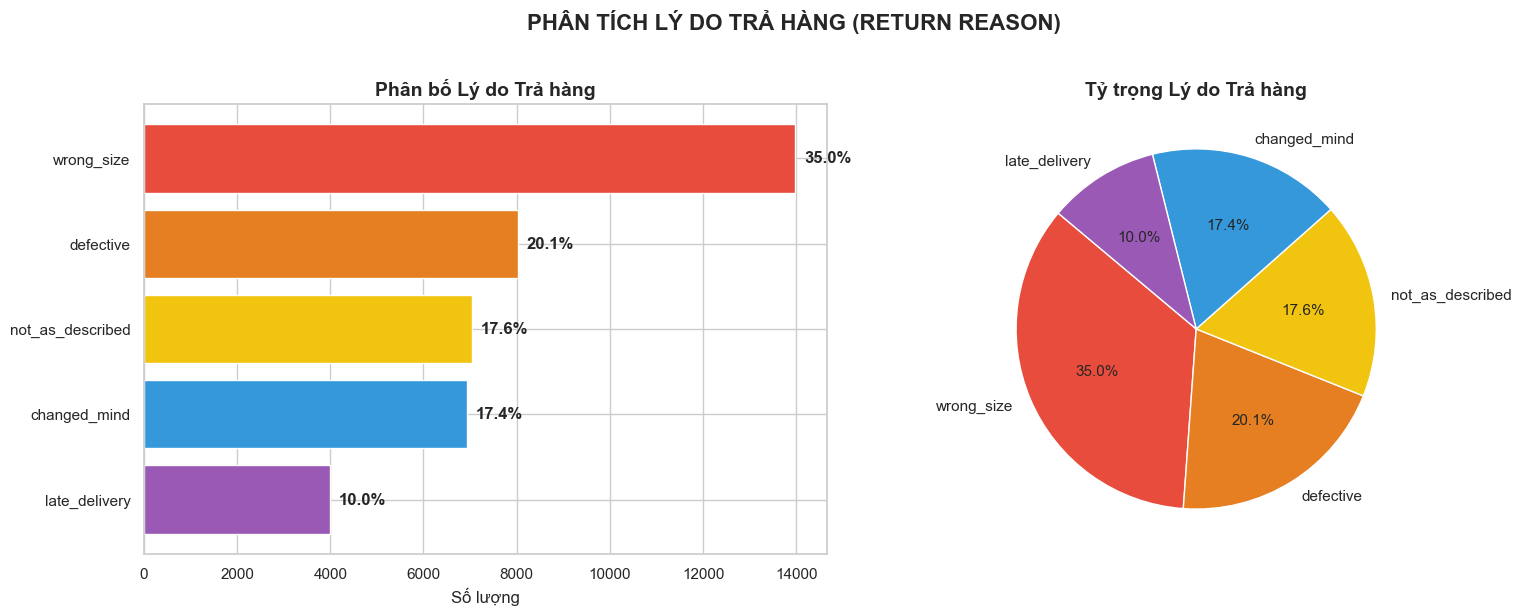


Chi tiết lý do trả hàng:
  wrong_size          : 13,967 (35.0%)
  defective           :  8,020 (20.1%)
  not_as_described    :  7,035 (17.6%)
  changed_mind        :  6,931 (17.4%)
  late_delivery       :  3,986 (10.0%)


In [7]:
# 4.1 Phân bố Return Reason
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Bar chart
reason_counts = df_returns['return_reason'].value_counts()
reason_pct = df_returns['return_reason'].value_counts(normalize=True) * 100
colors_reason = ['#e74c3c', '#e67e22', '#f1c40f', '#3498db', '#9b59b6']

bars = axes[0].barh(reason_counts.index[::-1], reason_counts.values[::-1], color=colors_reason[::-1], edgecolor='white')
for bar, pct in zip(bars, reason_pct.values[::-1]):
    axes[0].text(bar.get_width() + 200, bar.get_y() + bar.get_height()/2.,
                 f'{pct:.1f}%', va='center', fontsize=12, fontweight='bold')
axes[0].set_title('Phân bố Lý do Trả hàng', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Số lượng')

# Pie chart
axes[1].pie(reason_counts.values, labels=reason_counts.index, colors=colors_reason,
            autopct='%1.1f%%', startangle=140, textprops={'fontsize': 11})
axes[1].set_title('Tỷ trọng Lý do Trả hàng', fontsize=14, fontweight='bold')

plt.suptitle('PHÂN TÍCH LÝ DO TRẢ HÀNG (RETURN REASON)', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print('\nChi tiết lý do trả hàng:')
for reason, count in reason_counts.items():
    print(f'  {reason:20s}: {count:>6,} ({reason_pct[reason]:.1f}%)')

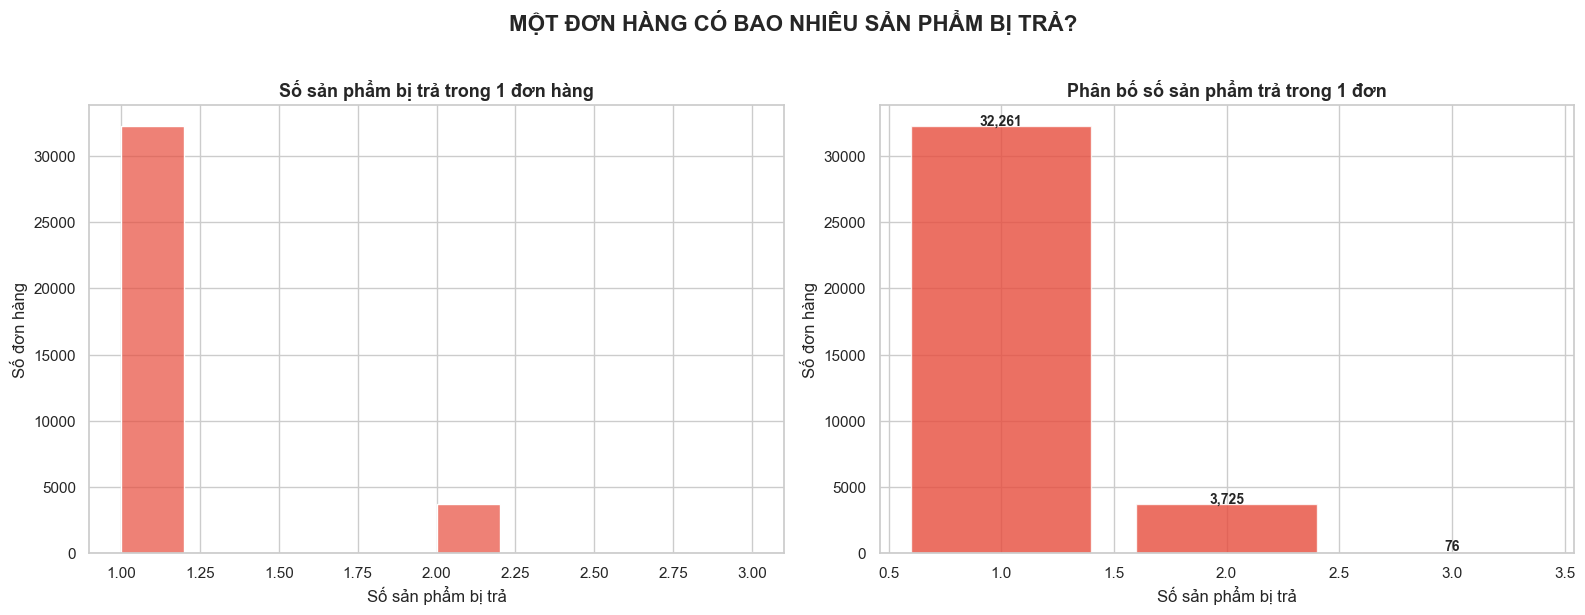

Thống kê:
  Trung bình: 1.11 sản phẩm/đơn
  Median: 1
  Max: 3


In [8]:
# 4.2 Số sản phẩm bị trả trong 1 đơn hàng
returns_per_order = df_returns.groupby('order_id').size().reset_index(name='n_returned_products')

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Histogram
sns.histplot(returns_per_order['n_returned_products'], bins=10, kde=False, ax=axes[0],
             color='#e74c3c', alpha=0.7, edgecolor='white')
axes[0].set_title('Số sản phẩm bị trả trong 1 đơn hàng', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Số sản phẩm bị trả')
axes[0].set_ylabel('Số đơn hàng')

# Value counts
n_ret_counts = returns_per_order['n_returned_products'].value_counts().sort_index()
bars = axes[1].bar(n_ret_counts.index, n_ret_counts.values, color='#e74c3c', alpha=0.8, edgecolor='white')
for bar, val in zip(bars, n_ret_counts.values):
    axes[1].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 100,
                 f'{val:,}', ha='center', fontsize=10, fontweight='bold')
axes[1].set_title('Phân bố số sản phẩm trả trong 1 đơn', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Số sản phẩm bị trả')
axes[1].set_ylabel('Số đơn hàng')

plt.suptitle('MỘT ĐƠN HÀNG CÓ BAO NHIÊU SẢN PHẨM BỊ TRẢ?', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(f'Thống kê:')
print(f'  Trung bình: {returns_per_order["n_returned_products"].mean():.2f} sản phẩm/đơn')
print(f'  Median: {returns_per_order["n_returned_products"].median():.0f}')
print(f'  Max: {returns_per_order["n_returned_products"].max()}')

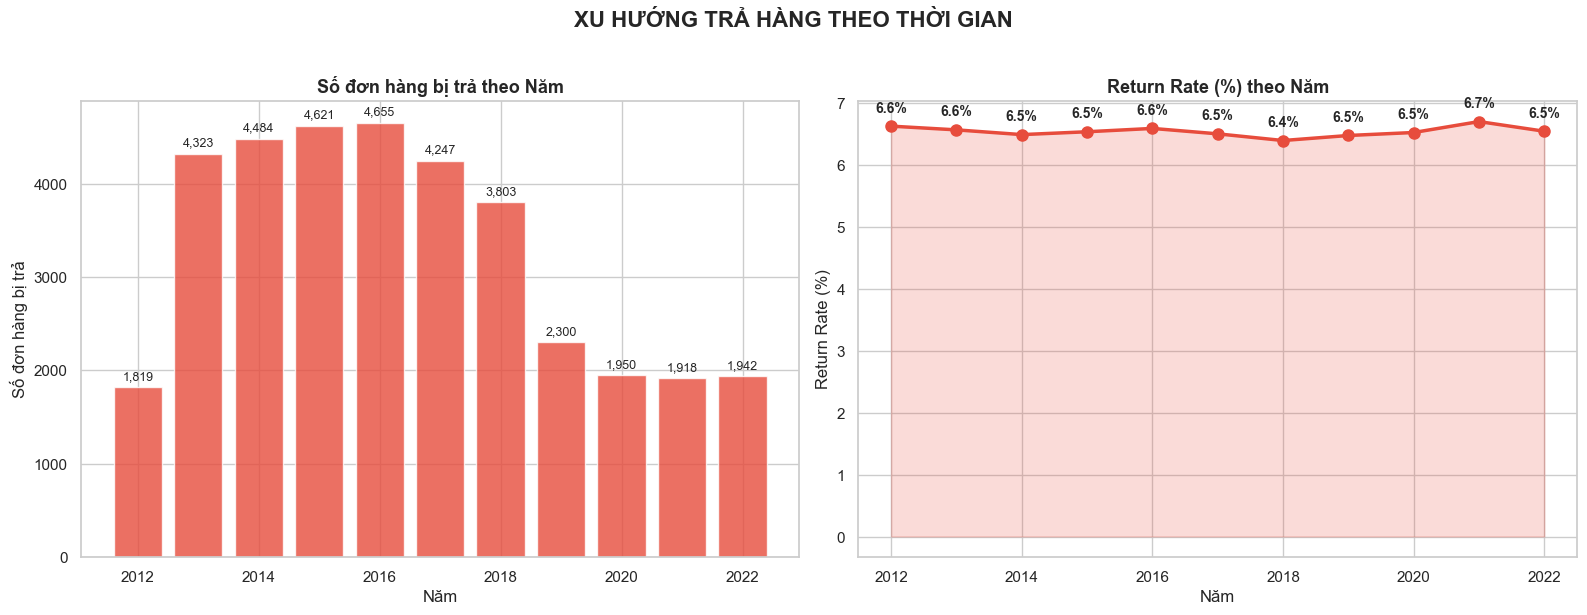

In [9]:
# 4.3 Xu hướng trả hàng theo thời gian
df_data['order_year'] = df_data['order_date'].dt.year
yearly_stats = df_data.groupby('order_year').agg(
    total_orders=('is_returned', 'count'),
    total_returns=('is_returned', 'sum')
).reset_index()
yearly_stats['return_rate'] = yearly_stats['total_returns'] / yearly_stats['total_orders'] * 100

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Số đơn trả hàng theo năm
bars = axes[0].bar(yearly_stats['order_year'], yearly_stats['total_returns'],
                   color='#e74c3c', alpha=0.8, edgecolor='white')
axes[0].set_title('Số đơn hàng bị trả theo Năm', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Năm')
axes[0].set_ylabel('Số đơn hàng bị trả')
for bar in bars:
    axes[0].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 50,
                 f'{int(bar.get_height()):,}', ha='center', va='bottom', fontsize=9)

# Return Rate theo năm
axes[1].plot(yearly_stats['order_year'], yearly_stats['return_rate'],
             marker='o', linewidth=2.5, color='#e74c3c', markersize=8)
axes[1].fill_between(yearly_stats['order_year'], yearly_stats['return_rate'],
                     alpha=0.2, color='#e74c3c')
axes[1].set_title('Return Rate (%) theo Năm', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Năm')
axes[1].set_ylabel('Return Rate (%)')
for x, y in zip(yearly_stats['order_year'], yearly_stats['return_rate']):
    axes[1].annotate(f'{y:.1f}%', (x, y), textcoords='offset points',
                     xytext=(0, 10), ha='center', fontsize=10, fontweight='bold')

plt.suptitle('XU HƯỚNG TRẢ HÀNG THEO THỜI GIAN', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 5. Phân tích Return Rate theo các chiều dữ liệu

Khảo sát tỷ lệ trả hàng ở **cấp đơn hàng** theo nhiều chiều khác nhau.

### 5.1 Return Rate theo Đặc điểm Đơn hàng (Số sản phẩm, Giá trị đơn, Discount)

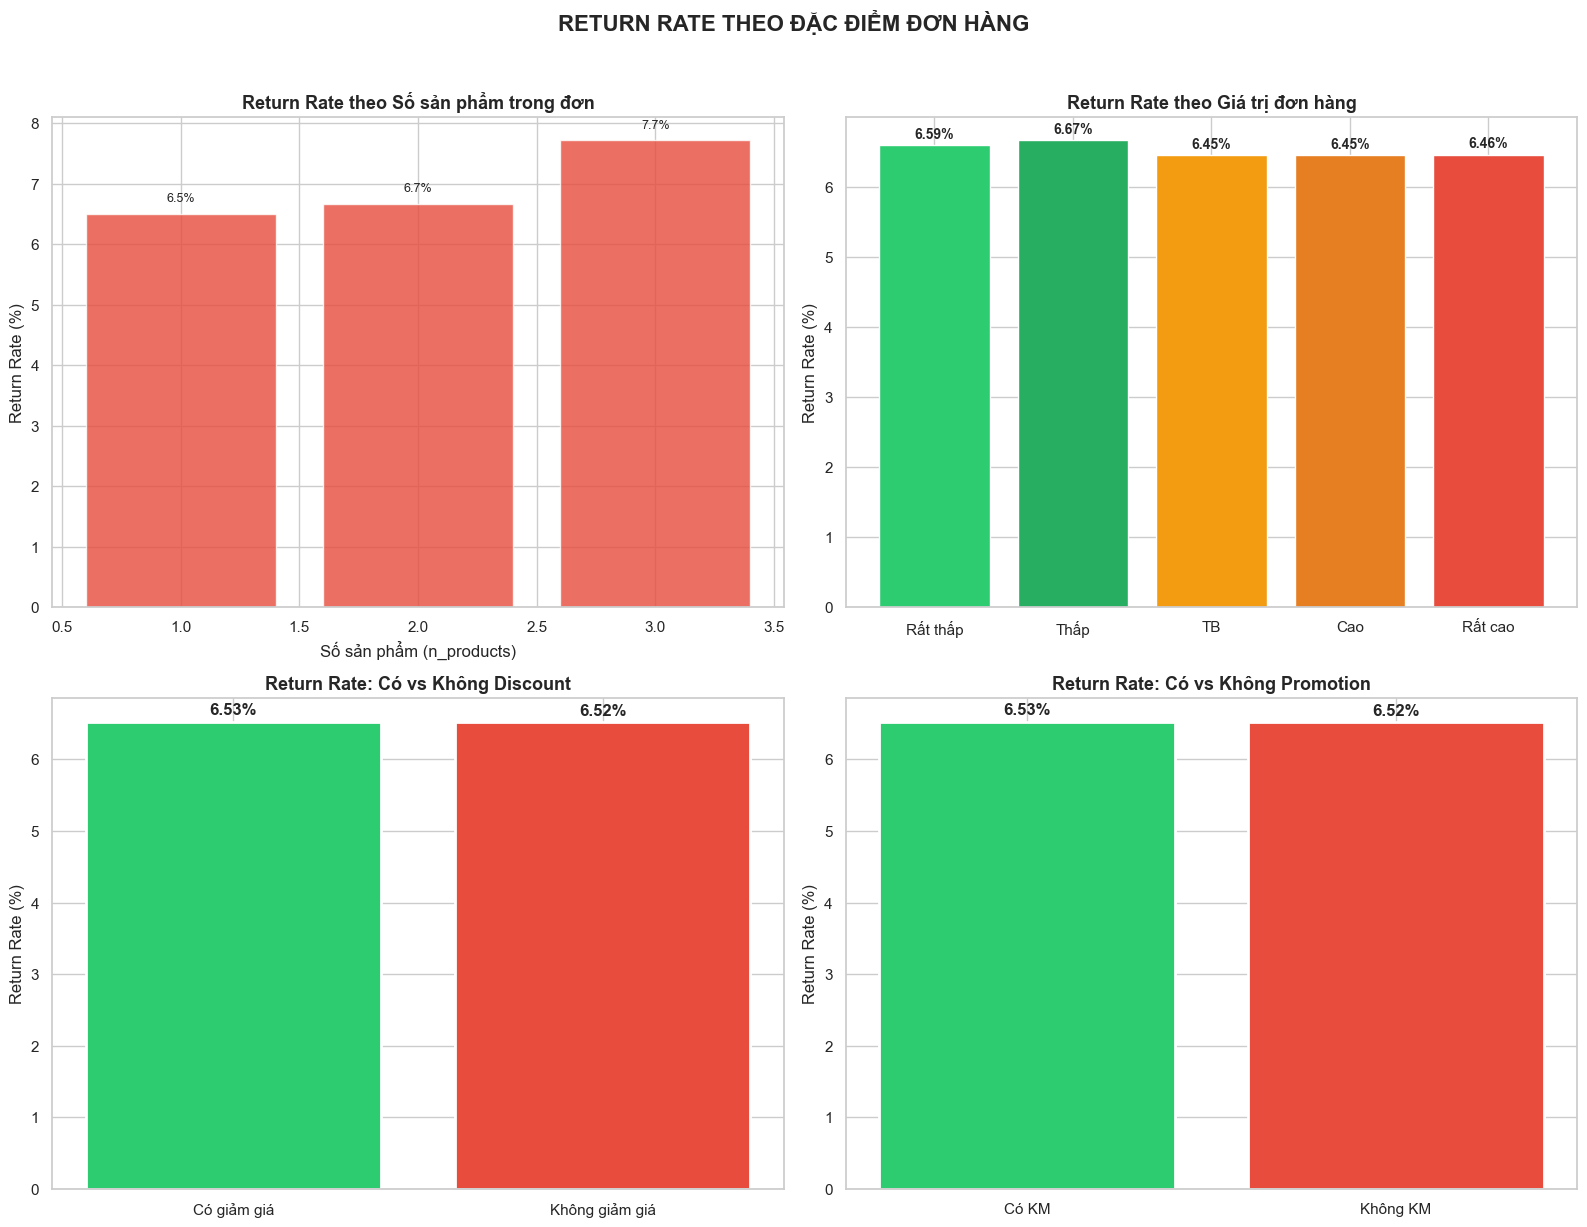

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# --- Số sản phẩm trong đơn ---
prod_stats = df_data.groupby('n_products').agg(
    total=('is_returned', 'count'), returns=('is_returned', 'sum')
).reset_index()
prod_stats['return_rate'] = prod_stats['returns'] / prod_stats['total'] * 100
prod_stats = prod_stats[prod_stats['total'] >= 50]  # Lọc nhóm quá nhỏ

axes[0, 0].bar(prod_stats['n_products'], prod_stats['return_rate'], color='#e74c3c', alpha=0.8, edgecolor='white')
for _, row in prod_stats.iterrows():
    axes[0, 0].text(row['n_products'], row['return_rate'] + 0.2,
                    f'{row["return_rate"]:.1f}%', ha='center', fontsize=9)
axes[0, 0].set_title('Return Rate theo Số sản phẩm trong đơn', fontsize=13, fontweight='bold')
axes[0, 0].set_xlabel('Số sản phẩm (n_products)')
axes[0, 0].set_ylabel('Return Rate (%)')

# --- Giá trị đơn hàng ---
df_data['value_bin'] = pd.qcut(df_data['order_total_value'], q=5, labels=['Rất thấp', 'Thấp', 'TB', 'Cao', 'Rất cao'])
val_stats = df_data.groupby('value_bin', observed=False).agg(
    total=('is_returned', 'count'), returns=('is_returned', 'sum')
).reset_index()
val_stats['return_rate'] = val_stats['returns'] / val_stats['total'] * 100

colors_val = ['#2ecc71', '#27ae60', '#f39c12', '#e67e22', '#e74c3c']
bars = axes[0, 1].bar(val_stats['value_bin'].astype(str), val_stats['return_rate'],
                       color=colors_val, edgecolor='white')
for bar, (_, row) in zip(bars, val_stats.iterrows()):
    axes[0, 1].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.1,
                    f'{row["return_rate"]:.2f}%', ha='center', fontsize=10, fontweight='bold')
axes[0, 1].set_title('Return Rate theo Giá trị đơn hàng', fontsize=13, fontweight='bold')
axes[0, 1].set_ylabel('Return Rate (%)')

# --- Discount ---
df_data['discount_label'] = df_data['has_any_discount'].map({0: 'Không giảm giá', 1: 'Có giảm giá'})
disc_stats = df_data.groupby('discount_label').agg(
    total=('is_returned', 'count'), returns=('is_returned', 'sum')
).reset_index()
disc_stats['return_rate'] = disc_stats['returns'] / disc_stats['total'] * 100

bars = axes[1, 0].bar(disc_stats['discount_label'], disc_stats['return_rate'],
                       color=['#2ecc71', '#e74c3c'], edgecolor='white', linewidth=2)
for bar, (_, row) in zip(bars, disc_stats.iterrows()):
    axes[1, 0].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.1,
                    f'{row["return_rate"]:.2f}%', ha='center', fontsize=12, fontweight='bold')
axes[1, 0].set_title('Return Rate: Có vs Không Discount', fontsize=13, fontweight='bold')
axes[1, 0].set_ylabel('Return Rate (%)')

# --- Promo ---
df_data['promo_label'] = df_data['has_any_promo'].map({0: 'Không KM', 1: 'Có KM'})
promo_stats = df_data.groupby('promo_label').agg(
    total=('is_returned', 'count'), returns=('is_returned', 'sum')
).reset_index()
promo_stats['return_rate'] = promo_stats['returns'] / promo_stats['total'] * 100

bars = axes[1, 1].bar(promo_stats['promo_label'], promo_stats['return_rate'],
                       color=['#2ecc71', '#e74c3c'], edgecolor='white', linewidth=2)
for bar, (_, row) in zip(bars, promo_stats.iterrows()):
    axes[1, 1].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.1,
                    f'{row["return_rate"]:.2f}%', ha='center', fontsize=12, fontweight='bold')
axes[1, 1].set_title('Return Rate: Có vs Không Promotion', fontsize=13, fontweight='bold')
axes[1, 1].set_ylabel('Return Rate (%)')

plt.suptitle('RETURN RATE THEO ĐẶC ĐIỂM ĐƠN HÀNG', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### 5.2 Return Rate theo Category chính (Dominant Category)

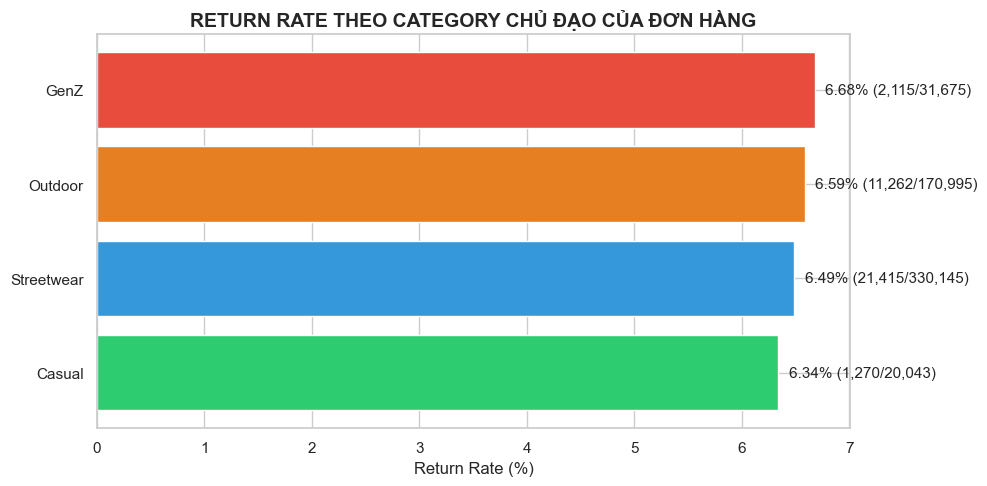

In [11]:
cat_stats = df_data.groupby('dominant_category').agg(
    total=('is_returned', 'count'), returns=('is_returned', 'sum')
).reset_index()
cat_stats['return_rate'] = cat_stats['returns'] / cat_stats['total'] * 100
cat_stats = cat_stats.sort_values('return_rate', ascending=True)

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(cat_stats['dominant_category'], cat_stats['return_rate'],
               color=['#2ecc71', '#3498db', '#e67e22', '#e74c3c'][:len(cat_stats)], edgecolor='white')
for bar, (_, row) in zip(bars, cat_stats.iterrows()):
    ax.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2.,
            f'{row["return_rate"]:.2f}% ({row["returns"]:,}/{row["total"]:,})',
            va='center', fontsize=11)
ax.set_title('RETURN RATE THEO CATEGORY CHỦ ĐẠO CỦA ĐƠN HÀNG', fontsize=14, fontweight='bold')
ax.set_xlabel('Return Rate (%)')
plt.tight_layout()
plt.show()

### 5.3 Return Rate theo Kênh đặt hàng (Device, Payment, Source)

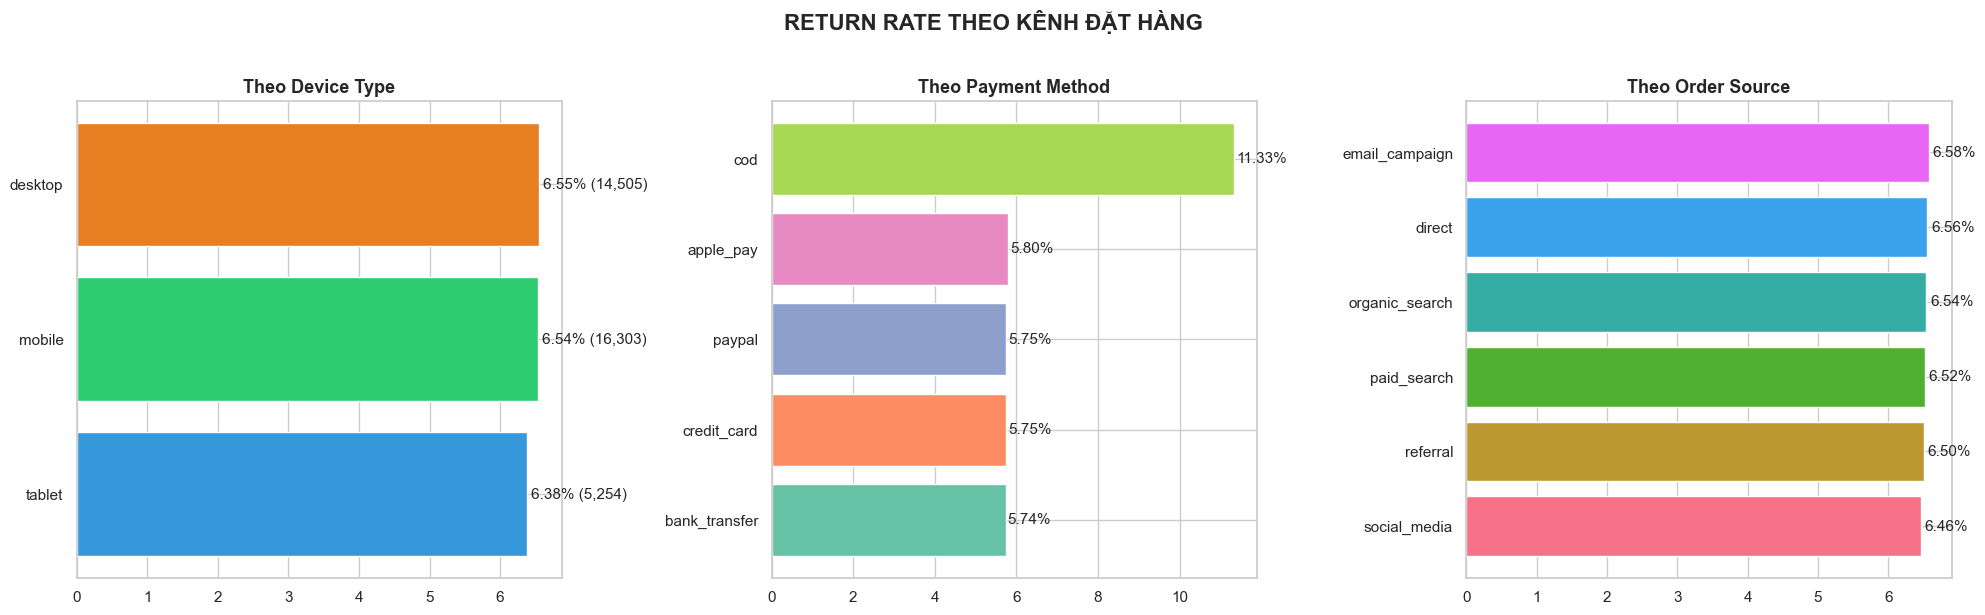

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# --- Device Type ---
device_stats = df_data.groupby('device_type').agg(
    total=('is_returned', 'count'), returns=('is_returned', 'sum')
).reset_index()
device_stats['return_rate'] = device_stats['returns'] / device_stats['total'] * 100
device_stats = device_stats.sort_values('return_rate', ascending=True)

bars = axes[0].barh(device_stats['device_type'], device_stats['return_rate'],
                     color=['#3498db', '#2ecc71', '#e67e22'], edgecolor='white')
for bar, (_, row) in zip(bars, device_stats.iterrows()):
    axes[0].text(bar.get_width() + 0.05, bar.get_y() + bar.get_height()/2.,
                  f'{row["return_rate"]:.2f}% ({row["returns"]:,})', va='center', fontsize=11)
axes[0].set_title('Theo Device Type', fontsize=13, fontweight='bold')

# --- Payment Method ---
pay_stats = df_data.groupby('payment_method').agg(
    total=('is_returned', 'count'), returns=('is_returned', 'sum')
).reset_index()
pay_stats['return_rate'] = pay_stats['returns'] / pay_stats['total'] * 100
pay_stats = pay_stats.sort_values('return_rate', ascending=True)

bars = axes[1].barh(pay_stats['payment_method'], pay_stats['return_rate'],
                     color=sns.color_palette('Set2', len(pay_stats)), edgecolor='white')
for bar, (_, row) in zip(bars, pay_stats.iterrows()):
    axes[1].text(bar.get_width() + 0.05, bar.get_y() + bar.get_height()/2.,
                  f'{row["return_rate"]:.2f}%', va='center', fontsize=11)
axes[1].set_title('Theo Payment Method', fontsize=13, fontweight='bold')

# --- Order Source ---
src_stats = df_data.groupby('order_source').agg(
    total=('is_returned', 'count'), returns=('is_returned', 'sum')
).reset_index()
src_stats['return_rate'] = src_stats['returns'] / src_stats['total'] * 100
src_stats = src_stats.sort_values('return_rate', ascending=True)

bars = axes[2].barh(src_stats['order_source'], src_stats['return_rate'],
                     color=sns.color_palette('husl', len(src_stats)), edgecolor='white')
for bar, (_, row) in zip(bars, src_stats.iterrows()):
    axes[2].text(bar.get_width() + 0.05, bar.get_y() + bar.get_height()/2.,
                  f'{row["return_rate"]:.2f}%', va='center', fontsize=11)
axes[2].set_title('Theo Order Source', fontsize=13, fontweight='bold')

plt.suptitle('RETURN RATE THEO KÊNH ĐẶT HÀNG', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 6. Phân tích Hành vi Khách hàng liên quan đến Trả hàng

### 6.1 Khách hàng mới (First Order) vs Khách cũ (Repeat Buyer)

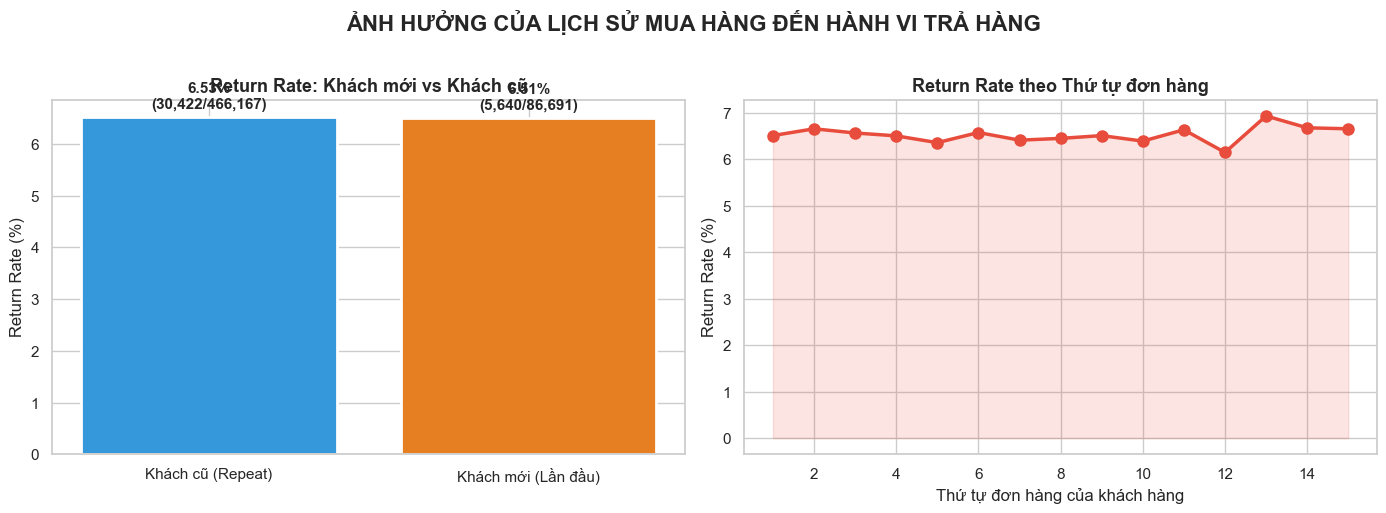

In [13]:
# Xác định khách hàng mới vs cũ
customer_order_rank = df_eligible.sort_values('order_date').groupby('customer_id')['order_id'].cumcount() + 1
order_rank_map = pd.DataFrame({
    'order_id': df_eligible.sort_values('order_date')['order_id'],
    'customer_order_number': customer_order_rank.values
})
df_data = df_data.merge(order_rank_map, on='order_id', how='left')
df_data['is_first_order'] = (df_data['customer_order_number'] == 1).astype(int)
df_data['customer_type'] = df_data['is_first_order'].map({1: 'Khách mới (Lần đầu)', 0: 'Khách cũ (Repeat)'})

cust_type_stats = df_data.groupby('customer_type').agg(
    total=('is_returned', 'count'), returns=('is_returned', 'sum')
).reset_index()
cust_type_stats['return_rate'] = cust_type_stats['returns'] / cust_type_stats['total'] * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Return rate
bars = axes[0].bar(cust_type_stats['customer_type'], cust_type_stats['return_rate'],
                   color=['#3498db', '#e67e22'], edgecolor='white', linewidth=2)
for bar, (_, row) in zip(bars, cust_type_stats.iterrows()):
    axes[0].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.1,
                 f'{row["return_rate"]:.2f}%\n({row["returns"]:,}/{row["total"]:,})',
                 ha='center', va='bottom', fontsize=11, fontweight='bold')
axes[0].set_title('Return Rate: Khách mới vs Khách cũ', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Return Rate (%)')

# Return rate theo customer order number (top 15)
order_num_stats = df_data.groupby('customer_order_number').agg(
    total=('is_returned', 'count'), returns=('is_returned', 'sum')
).reset_index()
order_num_stats['return_rate'] = order_num_stats['returns'] / order_num_stats['total'] * 100
order_num_stats = order_num_stats[order_num_stats['customer_order_number'] <= 15]

axes[1].plot(order_num_stats['customer_order_number'], order_num_stats['return_rate'],
             marker='o', linewidth=2.5, color='#e74c3c', markersize=8)
axes[1].fill_between(order_num_stats['customer_order_number'], order_num_stats['return_rate'],
                     alpha=0.15, color='#e74c3c')
axes[1].set_title('Return Rate theo Thứ tự đơn hàng', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Thứ tự đơn hàng của khách hàng')
axes[1].set_ylabel('Return Rate (%)')

plt.suptitle('ẢNH HƯỞNG CỦA LỊCH SỬ MUA HÀNG ĐẾN HÀNH VI TRẢ HÀNG', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### 6.2 Customer Demographics (Gender, Age Group, Region)

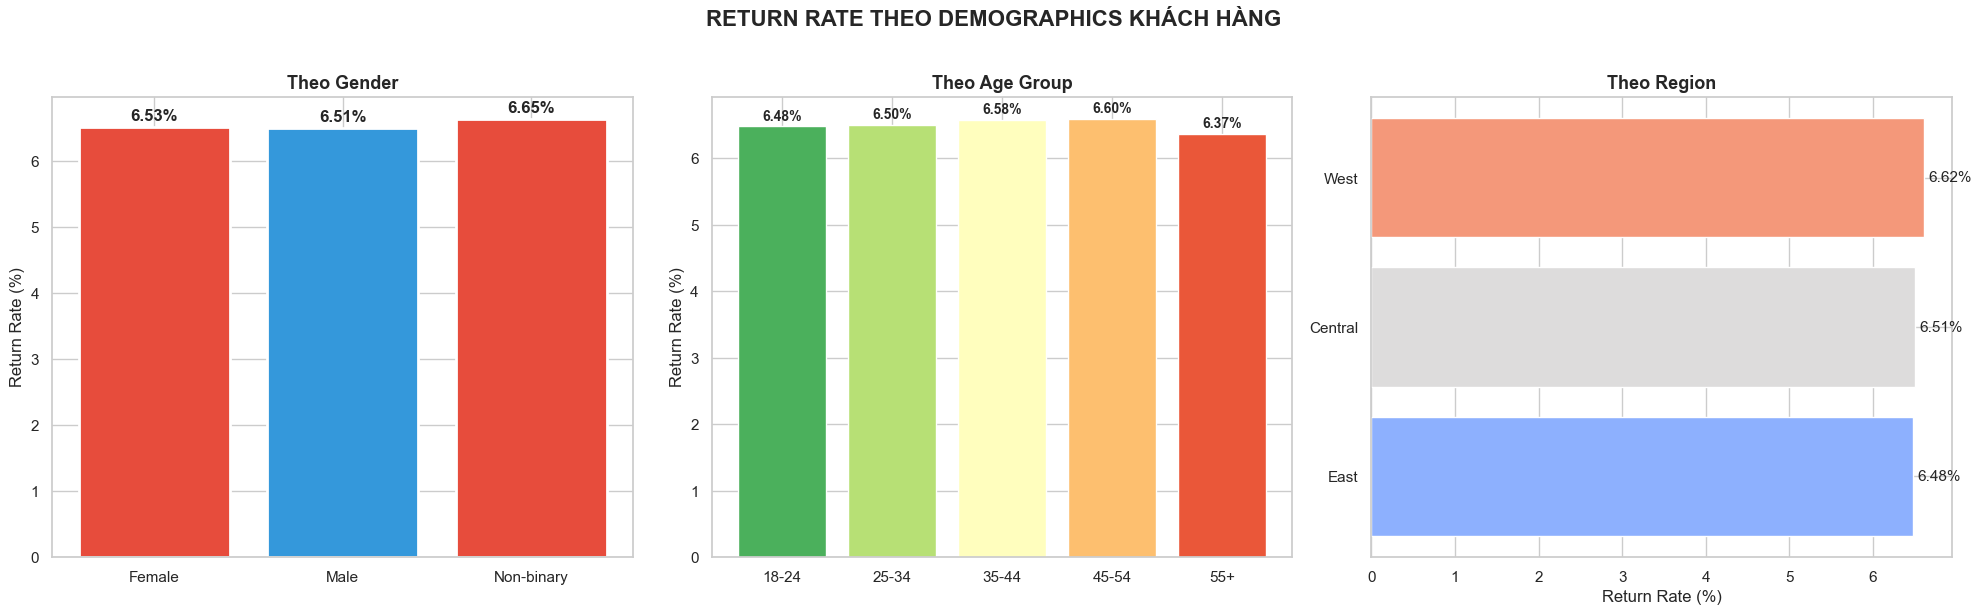

In [14]:
# Merge customer info
df_data = df_data.merge(df_customers[['customer_id', 'gender', 'age_group']], on='customer_id', how='left')
df_data = df_data.merge(df_geography[['zip', 'region']], on='zip', how='left')

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# --- Gender ---
gender_stats = df_data.groupby('gender').agg(
    total=('is_returned', 'count'), returns=('is_returned', 'sum')
).reset_index()
gender_stats['return_rate'] = gender_stats['returns'] / gender_stats['total'] * 100

bars = axes[0].bar(gender_stats['gender'], gender_stats['return_rate'],
                   color=['#e74c3c', '#3498db'], edgecolor='white', linewidth=2)
for bar, (_, row) in zip(bars, gender_stats.iterrows()):
    axes[0].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.05,
                 f'{row["return_rate"]:.2f}%', ha='center', va='bottom', fontsize=12, fontweight='bold')
axes[0].set_title('Theo Gender', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Return Rate (%)')

# --- Age Group ---
age_order = ['18-24', '25-34', '35-44', '45-54', '55+']
age_stats = df_data.groupby('age_group').agg(
    total=('is_returned', 'count'), returns=('is_returned', 'sum')
).reindex(age_order).reset_index()
age_stats['return_rate'] = age_stats['returns'] / age_stats['total'] * 100

axes[1].bar(age_stats['age_group'], age_stats['return_rate'],
            color=sns.color_palette('RdYlGn_r', len(age_stats)), edgecolor='white')
for i, (_, row) in enumerate(age_stats.iterrows()):
    axes[1].text(i, row['return_rate'] + 0.05, f'{row["return_rate"]:.2f}%',
                 ha='center', va='bottom', fontsize=10, fontweight='bold')
axes[1].set_title('Theo Age Group', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Return Rate (%)')

# --- Region ---
reg_stats = df_data.groupby('region').agg(
    total=('is_returned', 'count'), returns=('is_returned', 'sum')
).reset_index()
reg_stats['return_rate'] = reg_stats['returns'] / reg_stats['total'] * 100
reg_stats = reg_stats.sort_values('return_rate', ascending=True)

bars = axes[2].barh(reg_stats['region'], reg_stats['return_rate'],
                     color=sns.color_palette('coolwarm', len(reg_stats)), edgecolor='white')
for bar, (_, row) in zip(bars, reg_stats.iterrows()):
    axes[2].text(bar.get_width() + 0.05, bar.get_y() + bar.get_height()/2.,
                  f'{row["return_rate"]:.2f}%', va='center', fontsize=11)
axes[2].set_title('Theo Region', fontsize=13, fontweight='bold')
axes[2].set_xlabel('Return Rate (%)')

plt.suptitle('RETURN RATE THEO DEMOGRAPHICS KHÁCH HÀNG', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 7. Kiểm Định 4 Giả Thuyết

### 7.1 H1: Đơn hàng giá trị cao có tỷ lệ trả hàng cao hơn?

**Lý do:** Đơn hàng đắt tiền → kỳ vọng cao hơn → dễ thất vọng.

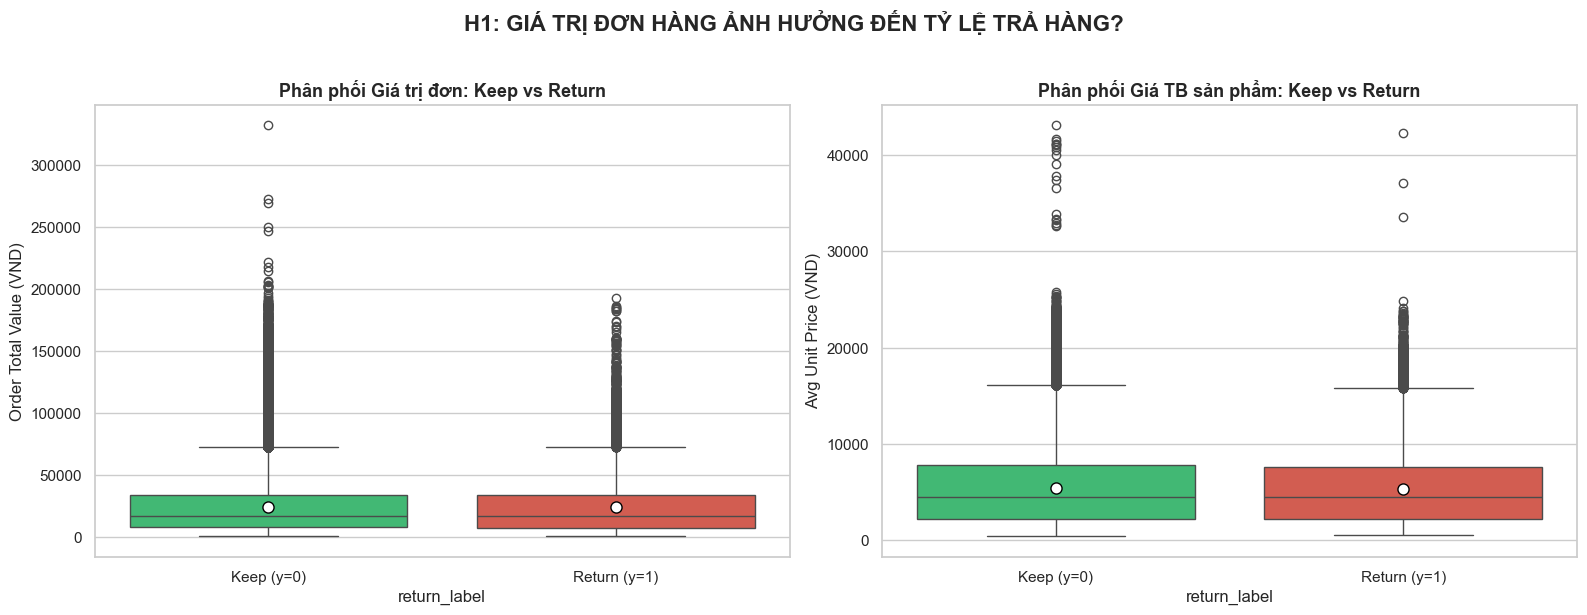

Thống kê giá trị đơn hàng theo nhóm:


,count,mean,std,min,25%,50%,75%,max
is_returned,,,,,,,,
0,516796.0,24226.116691,22352.242019,428.2,7682.1625,17242.31,33693.7175,331570.40
1,36062.0,23963.021223,22170.808213,443.9,7544.4700,16852.91,33534.0100,192672.32


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Boxplot: Order value vs Return
df_data['return_label'] = df_data['is_returned'].map({0: 'Keep (y=0)', 1: 'Return (y=1)'})
sns.boxplot(data=df_data, x='return_label', y='order_total_value', ax=axes[0],
            order=['Keep (y=0)', 'Return (y=1)'],
            palette={'Keep (y=0)': '#2ecc71', 'Return (y=1)': '#e74c3c'}, showmeans=True,
            meanprops={'marker':'o', 'markerfacecolor':'white', 'markeredgecolor':'black', 'markersize':8})
axes[0].set_title('Phân phối Giá trị đơn: Keep vs Return', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Order Total Value (VND)')

# Avg unit price
sns.boxplot(data=df_data, x='return_label', y='avg_unit_price', ax=axes[1],
            order=['Keep (y=0)', 'Return (y=1)'],
            palette={'Keep (y=0)': '#2ecc71', 'Return (y=1)': '#e74c3c'}, showmeans=True,
            meanprops={'marker':'o', 'markerfacecolor':'white', 'markeredgecolor':'black', 'markersize':8})
axes[1].set_title('Phân phối Giá TB sản phẩm: Keep vs Return', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Avg Unit Price (VND)')

plt.suptitle('H1: GIÁ TRỊ ĐƠN HÀNG ẢNH HƯỞNG ĐẾN TỶ LỆ TRẢ HÀNG?', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print('Thống kê giá trị đơn hàng theo nhóm:')
display(df_data.groupby('is_returned')['order_total_value'].describe())

### 7.2 H2: Đơn hàng COD có Return Rate cao hơn Credit Card?

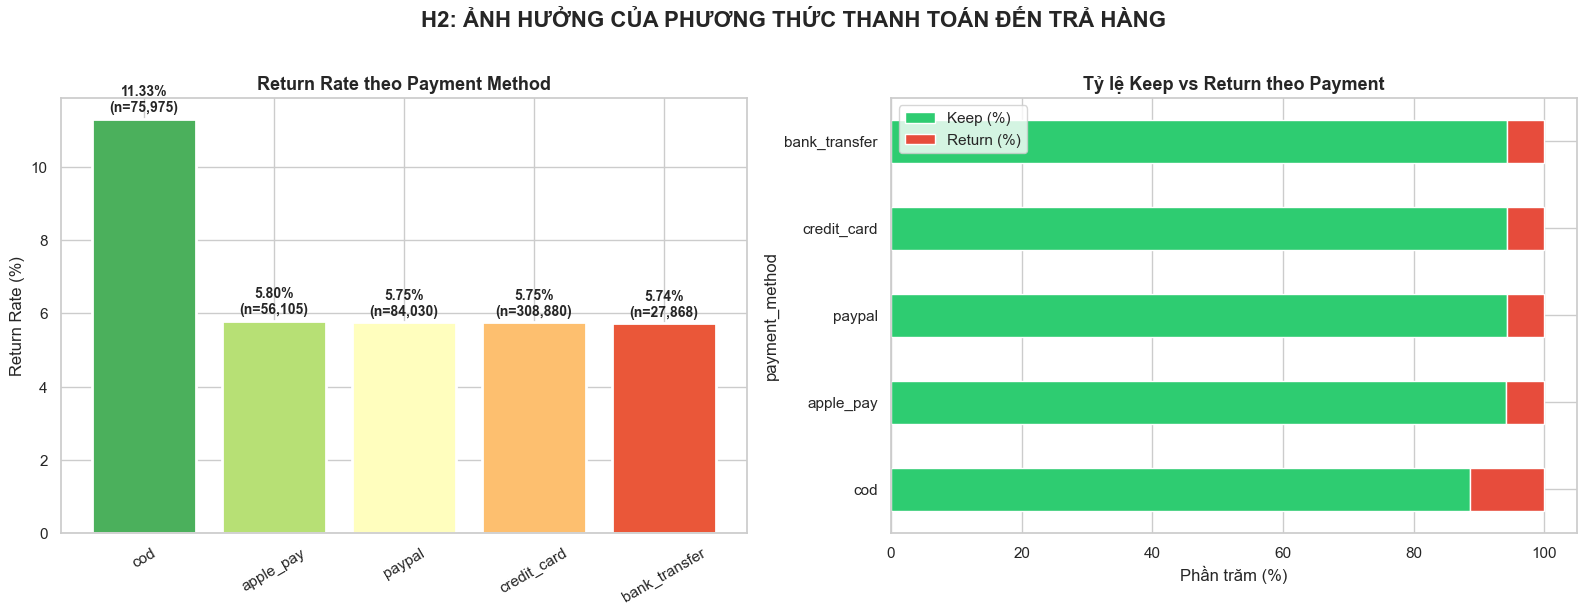

In [16]:
pay_detail = df_data.groupby('payment_method').agg(
    total=('is_returned', 'count'),
    returns=('is_returned', 'sum'),
    avg_value=('order_total_value', 'mean')
).reset_index()
pay_detail['return_rate'] = pay_detail['returns'] / pay_detail['total'] * 100
pay_detail = pay_detail.sort_values('return_rate', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Return Rate
colors_pay = sns.color_palette('RdYlGn_r', len(pay_detail))
bars = axes[0].bar(pay_detail['payment_method'], pay_detail['return_rate'],
                   color=colors_pay, edgecolor='white', linewidth=2)
for bar, (_, row) in zip(bars, pay_detail.iterrows()):
    axes[0].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.1,
                 f'{row["return_rate"]:.2f}%\n(n={row["total"]:,})',
                 ha='center', va='bottom', fontsize=10, fontweight='bold')
axes[0].set_title('Return Rate theo Payment Method', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Return Rate (%)')
axes[0].tick_params(axis='x', rotation=30)

# Stacked bar
pay_pivot = df_data.groupby(['payment_method', 'is_returned']).size().unstack(fill_value=0)
pay_pivot_pct = pay_pivot.div(pay_pivot.sum(axis=1), axis=0) * 100
pay_pivot_pct.columns = ['Keep (%)', 'Return (%)']
pay_pivot_pct = pay_pivot_pct.loc[pay_detail['payment_method']]
pay_pivot_pct.plot(kind='barh', stacked=True, ax=axes[1], color=['#2ecc71', '#e74c3c'],
                   edgecolor='white', linewidth=1)
axes[1].set_title('Tỷ lệ Keep vs Return theo Payment', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Phần trăm (%)')
axes[1].legend(fontsize=11)

plt.suptitle('H2: ẢNH HƯỞNG CỦA PHƯƠNG THỨC THANH TOÁN ĐẾN TRẢ HÀNG', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### 7.3 H3: Đơn đặt từ Mobile có Return Rate khác Desktop?

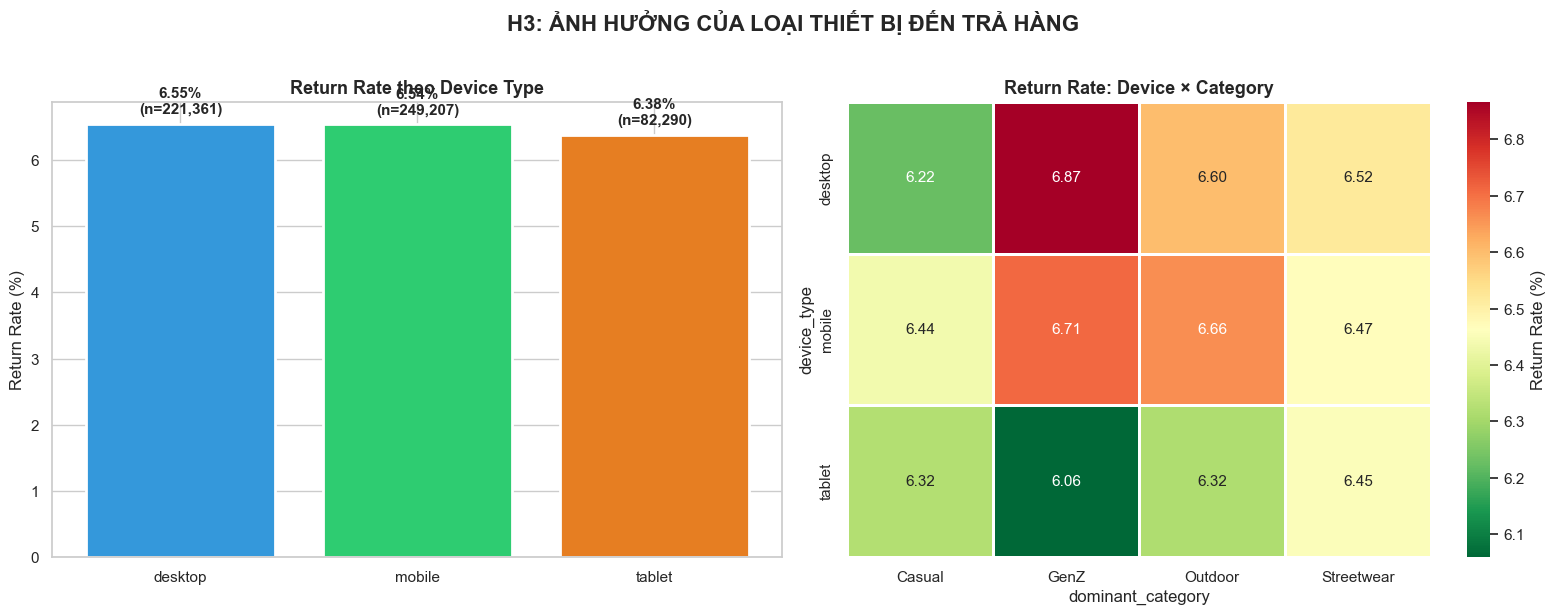

In [17]:
device_detail = df_data.groupby('device_type').agg(
    total=('is_returned', 'count'),
    returns=('is_returned', 'sum'),
    avg_value=('order_total_value', 'mean'),
    avg_n_products=('n_products', 'mean')
).reset_index()
device_detail['return_rate'] = device_detail['returns'] / device_detail['total'] * 100

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Return Rate by Device
bars = axes[0].bar(device_detail['device_type'], device_detail['return_rate'],
                   color=['#3498db', '#2ecc71', '#e67e22'], edgecolor='white', linewidth=2)
for bar, (_, row) in zip(bars, device_detail.iterrows()):
    axes[0].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.1,
                 f'{row["return_rate"]:.2f}%\n(n={row["total"]:,})',
                 ha='center', va='bottom', fontsize=11, fontweight='bold')
axes[0].set_title('Return Rate theo Device Type', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Return Rate (%)')

# Return Rate by Device x Category (heatmap)
# Cần lấy dominant_category cho heatmap
device_cat = df_data.groupby(['device_type', 'dominant_category']).agg(
    total=('is_returned', 'count'), returns=('is_returned', 'sum')
).reset_index()
device_cat['return_rate'] = device_cat['returns'] / device_cat['total'] * 100
heatmap_data = device_cat.pivot(index='device_type', columns='dominant_category', values='return_rate')

sns.heatmap(heatmap_data, annot=True, fmt='.2f', cmap='RdYlGn_r', ax=axes[1],
            linewidths=1, linecolor='white', cbar_kws={'label': 'Return Rate (%)'})
axes[1].set_title('Return Rate: Device × Category', fontsize=13, fontweight='bold')

plt.suptitle('H3: ẢNH HƯỞNG CỦA LOẠI THIẾT BỊ ĐẾN TRẢ HÀNG', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### 7.4 H4: Đơn hàng có nhiều sản phẩm dễ bị trả hơn?

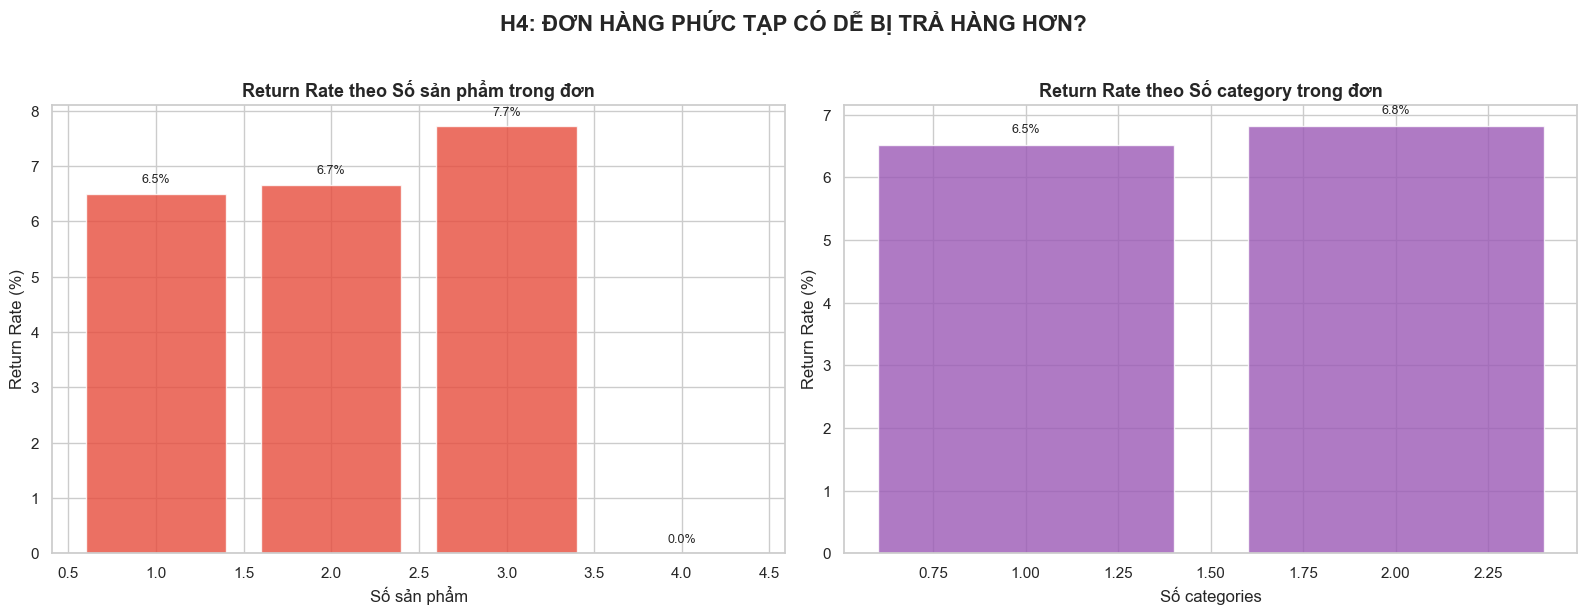

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# n_products vs return rate
nprod_stats = df_data.groupby('n_products').agg(
    total=('is_returned', 'count'), returns=('is_returned', 'sum')
).reset_index()
nprod_stats['return_rate'] = nprod_stats['returns'] / nprod_stats['total'] * 100
nprod_stats = nprod_stats[nprod_stats['total'] >= 30]

axes[0].bar(nprod_stats['n_products'], nprod_stats['return_rate'],
            color='#e74c3c', alpha=0.8, edgecolor='white')
for _, row in nprod_stats.iterrows():
    axes[0].text(row['n_products'], row['return_rate'] + 0.2,
                 f'{row["return_rate"]:.1f}%', ha='center', fontsize=9)
axes[0].set_title('Return Rate theo Số sản phẩm trong đơn', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Số sản phẩm')
axes[0].set_ylabel('Return Rate (%)')

# n_categories vs return rate
ncat_stats = df_data.groupby('n_categories').agg(
    total=('is_returned', 'count'), returns=('is_returned', 'sum')
).reset_index()
ncat_stats['return_rate'] = ncat_stats['returns'] / ncat_stats['total'] * 100
ncat_stats = ncat_stats[ncat_stats['total'] >= 30]

axes[1].bar(ncat_stats['n_categories'], ncat_stats['return_rate'],
            color='#9b59b6', alpha=0.8, edgecolor='white')
for _, row in ncat_stats.iterrows():
    axes[1].text(row['n_categories'], row['return_rate'] + 0.2,
                 f'{row["return_rate"]:.1f}%', ha='center', fontsize=9)
axes[1].set_title('Return Rate theo Số category trong đơn', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Số categories')
axes[1].set_ylabel('Return Rate (%)')

plt.suptitle('H4: ĐƠN HÀNG PHỨC TẠP CÓ DỄ BỊ TRẢ HÀNG HƠN?', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 8. Ma trận Tương quan

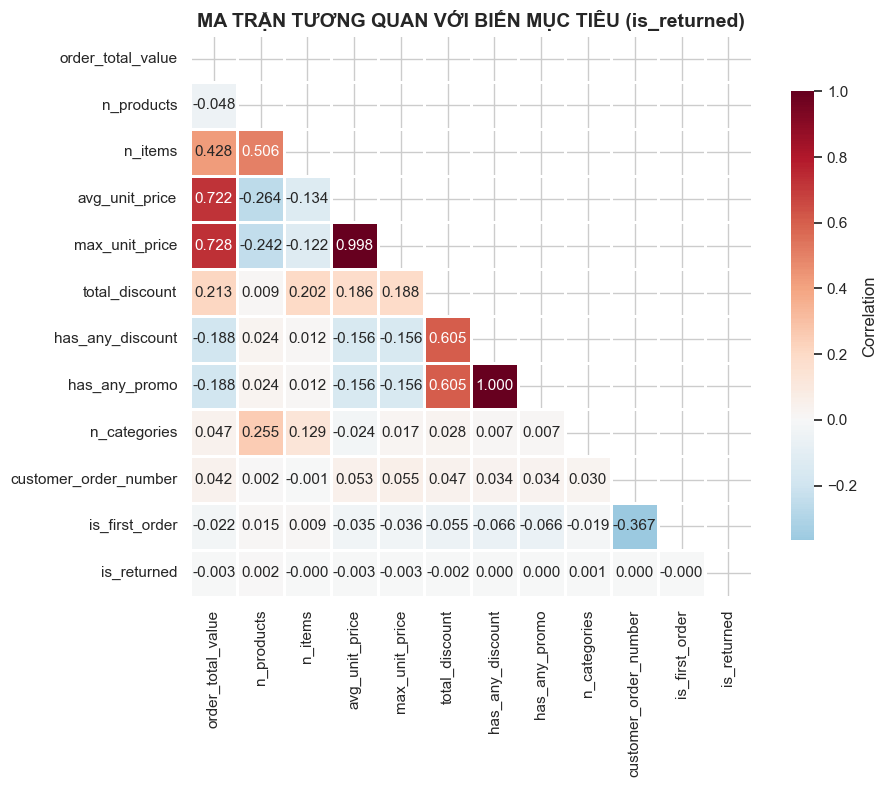


Tương quan với biến mục tiêu (is_returned):
  order_total_value             : -0.0029
  avg_unit_price                : -0.0028
  max_unit_price                : -0.0028
  n_products                    : +0.0022
  total_discount                : -0.0019
  n_categories                  : +0.0011
  customer_order_number         : +0.0005
  is_first_order                : -0.0003
  has_any_discount              : +0.0002
  has_any_promo                 : +0.0002
  n_items                       : -0.0001


In [19]:
numeric_cols = ['order_total_value', 'n_products', 'n_items', 'avg_unit_price',
                'max_unit_price', 'total_discount', 'has_any_discount', 'has_any_promo',
                'n_categories', 'customer_order_number', 'is_first_order', 'is_returned']
numeric_cols = [c for c in numeric_cols if c in df_data.columns]

corr_matrix = df_data[numeric_cols].corr()

plt.figure(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.3f', cmap='RdBu_r', center=0,
            square=True, linewidths=1, linecolor='white',
            cbar_kws={'shrink': 0.8, 'label': 'Correlation'})
plt.title('MA TRẬN TƯƠNG QUAN VỚI BIẾN MỤC TIÊU (is_returned)',
          fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('\nTương quan với biến mục tiêu (is_returned):')
target_corr = corr_matrix['is_returned'].drop('is_returned').sort_values(key=abs, ascending=False)
for feat, val in target_corr.items():
    print(f'  {feat:30s}: {val:+.4f}')

## 9. Tổng kết & Nhận xét Chính (Key Insights)

### Thống kê tổng quan:
- **Đơn vị dự báo:** `order_id` (cấp đơn hàng)
- **Tổng đơn hàng eligible:** ~552K đơn
- **Tỷ lệ trả hàng:** ~6.5% đơn hàng có ít nhất 1 sản phẩm bị trả
- **Class Imbalance:** 93.5% : 6.5% → Cần xử lý khi modeling

### Gợi ý cho Feature Engineering:
1. **Order-level features:** `n_products`, `order_total_value`, `avg_unit_price`, `has_discount`
2. **Customer-level features:** `customer_order_number`, historical return rate, demographics
3. **Channel features:** `payment_method`, `device_type`, `order_source`
4. **Temporal features:** `order_month`, `day_of_week`, `is_weekend`
5. **Product composition:** `n_categories`, `n_sizes`, `dominant_category`